# 04. Препроцессинг и фиксированный train/test split

**Цель:** воспроизвести baseline модель из статьи Pekar & Jozsa (2024) - Random Forest (RF) с дефолтными гиперпараметрами, на уже фиксированном train/test split. Получить референсные значения 12 метрик, относительно которых будут далее сравниваться другие модели.

**Замечание:**
1) Артефакт модели будет сохранен 

In [1]:
from __future__ import annotations

import json
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    confusion_matrix,
)

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ------- Пути -------
try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR

CACHE_DIR  = PROJECT_ROOT / "cache"
ARTIFACTS  = PROJECT_ROOT / "artifacts"
FIG_DIR    = PROJECT_ROOT / "results" / "figures"
TAB_DIR    = PROJECT_ROOT / "results" / "tables"
SRC_DIR    = PROJECT_ROOT / "src"
for p in (FIG_DIR, TAB_DIR):
    p.mkdir(parents=True, exist_ok=True)

# чтобы импортировать src.metrics
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.metrics import compute_binary_metrics, confusion_matrix_dict  # noqa: E402

print("sklearn:", sklearn.__version__)
print("PROJECT_ROOT:", PROJECT_ROOT)

sklearn: 1.8.0
PROJECT_ROOT: /workspace


In [2]:
X_train = pd.read_parquet(CACHE_DIR / "X_train.parquet")
X_test  = pd.read_parquet(CACHE_DIR / "X_test.parquet")
y_train = pd.read_parquet(CACHE_DIR / "y_train.parquet")["target"].values
y_test  = pd.read_parquet(CACHE_DIR / "y_test.parquet" )["target"].values

# Загрузка конфига препроцессора и MODEL_FEATURES
with (ARTIFACTS / "preprocessing_config.json").open() as f:
    pp_config = json.load(f)
MODEL_FEATURES = pp_config["model_features"]
assert len(MODEL_FEATURES) == 42

# проверки: данные согласованы с конфигом
assert list(X_train.columns) == MODEL_FEATURES
assert list(X_test.columns)  == MODEL_FEATURES
assert X_train.shape[1] == 42 and X_test.shape[1] == 42

print(f"X_train: {X_train.shape} | anomaly: {y_train.mean()*100:.2f}%")
print(f"X_test:  {X_test.shape}  | anomaly: {y_test.mean()*100:.2f}%")
print(f"MODEL_FEATURES: {len(MODEL_FEATURES)}")

X_train: (1477791, 42) | anomaly: 23.63%
X_test:  (633340, 42)  | anomaly: 23.63%
MODEL_FEATURES: 42


## 1. Baseline подходы 

Перед обучением RF, стоит обозначить так называемый - нижний потолок. Это минимально доступное качество, получаемое простейшими статистическими методами.

На основе этого вот три baseline:
1) **Majority class** - всегда предсказывание BENIGN. `F1_anmaly` должен быть 0 (так как ни родной аномалии не предсказано), accuracy ~= 76% (ранво доле BENIGN в test).

2) **RST-правило** - если `bidirectional_rst_packets > 0`, предсказывается ANOMALY. Без ML, одной строкой.

3) **Логрегрессия на одном `bidirectional_rst_packets`** - единственная фича. Должна дать примерно те же числа, что и правило (логрегрессия на одной фиче — это просто оптимальный порог).


In [3]:
df_full = pd.read_parquet(CACHE_DIR / "nfs_2023_nte_all.parquet",
                          columns=["bidirectional_rst_packets", "label"])

from sklearn.model_selection import train_test_split
y_full = (df_full["label"].astype(str).str.strip().str.upper() != "BENIGN").astype(np.int64)

_, rst_test_raw, _, y_test_check = train_test_split(
    df_full["bidirectional_rst_packets"].values,
    y_full.values,
    test_size=0.30, stratify=y_full.values, random_state=RANDOM_STATE,
)

print(f"Сырые значения rst_packets для test восстановлены: {rst_test_raw.shape}")

# --- Baseline 1: majority class --------------------------------------------
y_pred_majority = np.zeros_like(y_test)
m1 = compute_binary_metrics(y_test, y_pred_majority, y_score=None)

# --- Baseline 2: правило rst > 0 -------------------------------------------
y_pred_rst_rule = (rst_test_raw > 0).astype(np.int64)
m2 = compute_binary_metrics(y_test, y_pred_rst_rule, y_score=rst_test_raw.astype(float))

# --- Baseline 3: LogReg на одной фиче rst (на скейленных данных) -----------
rst_col_pp = X_train["bidirectional_rst_packets"].values.reshape(-1, 1)
rst_test_pp = X_test ["bidirectional_rst_packets"].values.reshape(-1, 1)
logreg_rst = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
logreg_rst.fit(rst_col_pp, y_train)
y_score_lr = logreg_rst.predict_proba(rst_test_pp)[:, 1]
y_pred_lr  = (y_score_lr >= 0.5).astype(np.int64)
m3 = compute_binary_metrics(y_test, y_pred_lr, y_score=y_score_lr)

# Сводная таблица
sanity = pd.DataFrame({
    "majority":     m1,
    "rst_rule":     m2,
    "logreg_on_rst": m3,
}).T
sanity = sanity.round(4)
sanity.to_csv(TAB_DIR / "baseline_sanity_metrics.csv")
print(sanity[["accuracy", "f1_anomaly", "precision_anomaly", "recall_anomaly",
              "roc_auc", "pr_auc"]].to_string())

Сырые значения rst_packets для test восстановлены: (633340,)
               accuracy  f1_anomaly  precision_anomaly  recall_anomaly  roc_auc  pr_auc
majority         0.7637      0.0000             0.0000          0.0000      NaN     NaN
rst_rule         0.9111      0.8284             0.7618          0.9076   0.9011  0.6833
logreg_on_rst    0.9111      0.8284             0.7618          0.9076   0.9011  0.6833


## 2. Обучение Random Forest

Гиперпараметры:
- `n_estimators=100` (дефолт sklearn).
- `criterion="gini"` (дефолт).
- `max_depth=None` (полные деревья - на 1.5M train и 42 фичах это дает
  глубокие деревья и большой объём памяти, но всё ещё помещается в 32GB).
- `min_samples_split=2`, `min_samples_leaf=1` (дефолт).
- `max_features="sqrt"` (дефолт sqrt(42)~=6 фич на split).
- `bootstrap=True` (дефолт).
- `class_weight=None` (НЕ балансируем — намеренно, по итогоам `02-ноутбука`).
- `n_jobs=-1`.
- `random_state=42`.

In [4]:
rf_params = {
    "n_estimators":      100,
    "criterion":         "gini",
    "max_depth":         None,
    "min_samples_split": 2,
    "min_samples_leaf":  1,
    "max_features":      "sqrt",
    "bootstrap":         True,
    "class_weight":      None,
    "n_jobs":            -1,
    "random_state":      RANDOM_STATE,
    "verbose":           1,
}
print("RF params:", rf_params)

rf = RandomForestClassifier(**rf_params)

t0 = time.time()
rf.fit(X_train.values, y_train)
fit_time = time.time() - t0
print(f"\Время обучения {fit_time:.1f} сек")

RF params: {'n_estimators': 100, 'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None, 'n_jobs': -1, 'random_state': 42, 'verbose': 1}


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   10.7s


\Время обучения 28.8 сек


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   28.6s finished


In [5]:
t0 = time.time()
y_pred_test  = rf.predict(X_test.values)
y_score_test = rf.predict_proba(X_test.values)[:, 1]
predict_time_test = time.time() - t0

# train — для overfit-check
y_pred_train  = rf.predict(X_train.values)
y_score_train = rf.predict_proba(X_train.values)[:, 1]

metrics_test  = compute_binary_metrics(y_test,  y_pred_test,  y_score_test)
metrics_train = compute_binary_metrics(y_train, y_pred_train, y_score_train)
cm_test  = confusion_matrix_dict(y_test,  y_pred_test)
cm_train = confusion_matrix_dict(y_train, y_pred_train)

print(f"Predict (test):  {predict_time_test:.1f} сек на {len(y_test):,} flow")
print(f"  throughput: {len(y_test) / predict_time_test:,.0f} flow/sec\n")

mt = pd.DataFrame({"train": metrics_train, "test": metrics_test}).round(4)
print(mt.to_string())
print(f"\nConfusion matrix (test): {cm_test}")
print(f"Overfit gap (f1_anomaly): {metrics_train['f1_anomaly'] - metrics_test['f1_anomaly']:+.4f}")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.6s finished


Predict (test):  0.6 сек на 633,340 flow
  throughput: 1,121,922 flow/sec

                    train    test
accuracy           0.9995  0.9994
precision_anomaly  0.9978  0.9977
recall_anomaly     0.9999  0.9998
f1_anomaly         0.9989  0.9988
precision_benign   1.0000  0.9999
recall_benign      0.9993  0.9993
f1_benign          0.9997  0.9996
f1_macro           0.9993  0.9992
f1_weighted        0.9995  0.9994
balanced_accuracy  0.9996  0.9996
roc_auc            0.9999  0.9999
pr_auc             0.9996  0.9995

Confusion matrix (test): {'tn': 483340, 'fp': 341, 'fn': 25, 'tp': 149634}
Overfit gap (f1_anomaly): +0.0001


## 3. ROC, PR-curve, confusion matrix

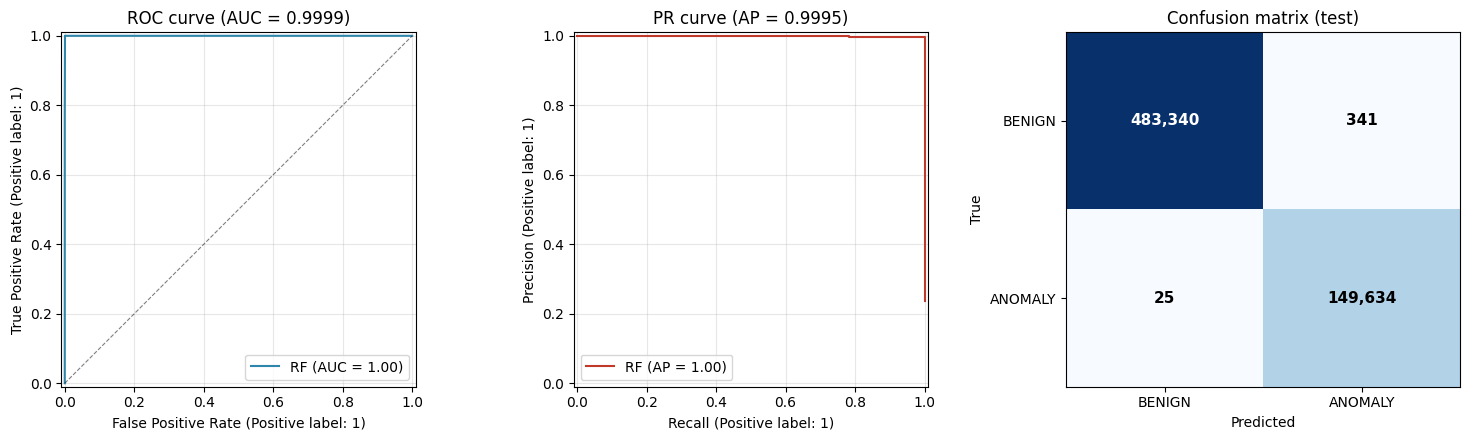

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ROC
RocCurveDisplay.from_predictions(y_test, y_score_test, name="RF",
                                  ax=axes[0], color="#2E86AB")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
axes[0].set_title(f"ROC curve (AUC = {metrics_test['roc_auc']:.4f})")
axes[0].grid(alpha=0.3)

# PR
PrecisionRecallDisplay.from_predictions(y_test, y_score_test, name="RF",
                                         ax=axes[1], color="#C0392B")
axes[1].set_title(f"PR curve (AP = {metrics_test['pr_auc']:.4f})")
axes[1].grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
im = axes[2].imshow(cm, cmap="Blues", aspect="auto")
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["BENIGN", "ANOMALY"])
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["BENIGN", "ANOMALY"])
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
axes[2].set_title("Confusion matrix (test)")
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        axes[2].text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                     color=color, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_04_rf_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Feature importance: Gini и Permutation

**Gini importance** (она же MDI, Mean Decrease in Impurity) — встроенная
в sklearn, мгновенная.

**Permutation importance** на test — считается правильным способом:
перемешиваем значения фичи и смотрим, насколько падает F1.

In [7]:
# --- Gini importance ---
gini_imp = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "gini_importance": rf.feature_importances_,
}).sort_values("gini_importance", ascending=False).reset_index(drop=True)

# --- Permutation importance (на сэмпле 50k из test) ---
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=50_000, replace=False)
X_test_sample = X_test.iloc[sample_idx].values
y_test_sample = y_test[sample_idx]

print("Считаю permutation importance (n_repeats=5, n_jobs=-1)... это 5-15 мин")
t0 = time.time()
perm = permutation_importance(
    rf, X_test_sample, y_test_sample,
    n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE, scoring="f1",
)
print(f"  permutation готова за {time.time() - t0:.1f} сек")

perm_imp = pd.DataFrame({
    "feature":         MODEL_FEATURES,
    "perm_importance": perm.importances_mean,
    "perm_std":        perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

imp = gini_imp.merge(perm_imp, on="feature")
imp.to_csv(TAB_DIR / "rf_feature_importance.csv", index=False)
print(f"\nТоп-15 по Gini:")
print(imp.head(15).to_string(index=False))

Считаю permutation importance (n_repeats=5, n_jobs=-1)... это 5-15 мин


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | ela

  permutation готова за 4.9 сек

Топ-15 по Gini:
                  feature  gini_importance  perm_importance  perm_std
bidirectional_rst_packets         0.100814         0.001711  0.000138
            dst2src_bytes         0.091362        -0.000160  0.000049
        dst2src_stddev_ps         0.088990         0.000965  0.000143
          dst2src_mean_ps         0.085745        -0.000202  0.000017
           dst2src_max_ps         0.076635        -0.000236  0.000021
  bidirectional_stddev_ps         0.069575        -0.000185  0.000069
     bidirectional_max_ps         0.049965        -0.000227  0.000034
    bidirectional_mean_ps         0.045513        -0.000261  0.000041
            src2dst_bytes         0.041054        -0.000219  0.000032
bidirectional_ack_packets         0.040826        -0.000118  0.000032
          src2dst_mean_ps         0.039895        -0.000185  0.000034
bidirectional_syn_packets         0.029430         0.077189  0.001044
           src2dst_max_ps         0.02907

[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


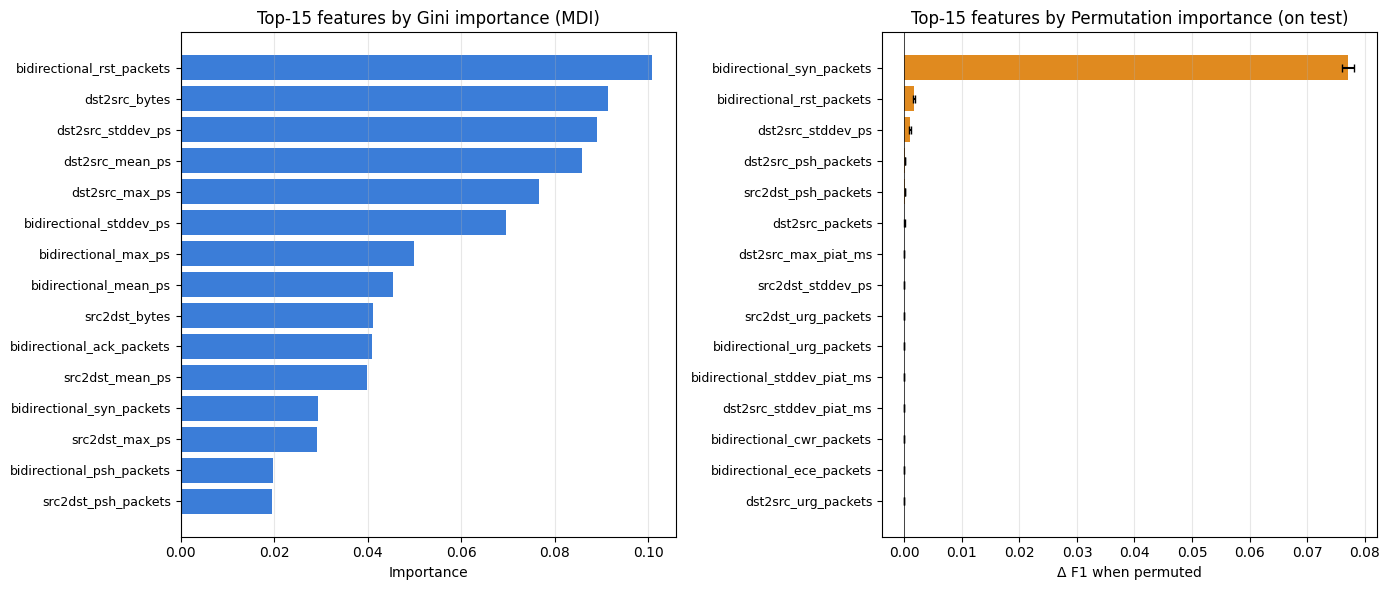

In [8]:
top15_gini = imp.head(15)
top15_perm = imp.sort_values("perm_importance", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gini
axes[0].barh(top15_gini["feature"][::-1], top15_gini["gini_importance"][::-1],
             color="#3B7DD8")
axes[0].set_title("Top-15 features by Gini importance (MDI)")
axes[0].set_xlabel("Importance")
axes[0].tick_params(axis="y", labelsize=9)
axes[0].grid(axis="x", alpha=0.3)

# Permutation
axes[1].barh(top15_perm["feature"][::-1], top15_perm["perm_importance"][::-1],
             xerr=top15_perm["perm_std"][::-1], color="#E08A1F", capsize=3)
axes[1].set_title("Top-15 features by Permutation importance (on test)")
axes[1].set_xlabel("Δ F1 when permuted")
axes[1].tick_params(axis="y", labelsize=9)
axes[1].grid(axis="x", alpha=0.3)
axes[1].axvline(0, color="black", lw=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_04_rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Анализ ошибок по типам атак

In [9]:
df_labels = pd.read_parquet(
    CACHE_DIR / "nfs_2023_nte_all.parquet",
    columns=["label"]
)

label_raw = df_labels["label"].to_numpy(dtype=object)
y_full_np = y_full.to_numpy() if hasattr(y_full, "to_numpy") else np.asarray(y_full)

idx = np.arange(len(y_full_np))

_, test_idx = train_test_split(
    idx,
    test_size=0.30,
    stratify=y_full_np,
    random_state=RANDOM_STATE,
)

label_test_raw = label_raw[test_idx]

assert len(label_test_raw) == len(y_test)
assert len(label_test_raw) == len(y_pred_test)

err = pd.DataFrame({
    "label":  label_test_raw,
    "y_true": np.asarray(y_test),
    "y_pred": np.asarray(y_pred_test),
})

err["correct"] = (err["y_true"] == err["y_pred"]).astype(int)

per_class = err.groupby("label").agg(
    n_total=("y_true", "size"),
    n_correct=("correct", "sum"),
).reset_index()

per_class["accuracy"] = (per_class["n_correct"] / per_class["n_total"]).round(4)
per_class["n_errors"] = per_class["n_total"] - per_class["n_correct"]

per_class = per_class.sort_values("n_total", ascending=False)

per_class.to_csv(TAB_DIR / "rf_errors_per_attack_type.csv", index=False)

print("Точность RF по каждому исходному label:")
print(per_class.to_string(index=False))

Точность RF по каждому исходному label:
                     label  n_total  n_correct  accuracy  n_errors
                    BENIGN   483681     483340    0.9993       341
                  PortScan    67137      67133    0.9999         4
                  DoS Hulk    47623      47623    1.0000         0
                      DDoS    27906      27906    1.0000         0
             DoS GoldenEye     2375       2375    1.0000         0
             DoS slowloris     1555       1554    0.9994         1
               FTP-Patator     1155       1155    1.0000         0
               SSH-Patator      859        857    0.9977         2
          DoS Slowhttptest      758        749    0.9881         9
                       Bot      226        226    1.0000         0
  Web Attack - Brute Force       45         44    0.9778         1
              Infiltration        7          4    0.5714         3
          Web Attack - XSS        6          4    0.6667         2
                Heartb

## 6. Сохранение артефакта модели

In [10]:
artifact = {
    # --- идентификация ---
    "model_class_name":  "RandomForestClassifier",
    "model_name_human":  "RF baseline (default sklearn params)",
    "model_file":        "model_rf_baseline.joblib",

    # --- сам объект ---
    "model":             rf,

    # --- контракт на признаки ---
    "model_features":    MODEL_FEATURES,
    "n_features":        42,
    "preprocessor_path": "preprocessor.joblib",

    # --- метрики ---
    "metrics_test":      metrics_test,
    "metrics_train":     metrics_train,
    "confusion_matrix_test":  cm_test,
    "confusion_matrix_train": cm_train,

    # --- настройки обучения ---
    "training_config":   rf_params,
    "fit_time_sec":      float(fit_time),
    "predict_time_test_sec": float(predict_time_test),
    "test_size":         0.30,
    "train_size":        int(len(y_train)),

    # --- API для inference ---
    "score_type":        "predict_proba",
    "decision_threshold": 0.5,

    # --- среда воспроизведения ---
    "random_state":      RANDOM_STATE,
    "sklearn_version":   sklearn.__version__,
    "python_version":    sys.version.split()[0],
    "timestamp":         datetime.now().isoformat(timespec="seconds"),
}

out_path = ARTIFACTS / "model_rf_baseline.joblib"
joblib.dump(artifact, out_path, compress=3)
size_mb = out_path.stat().st_size / 1024**2
print(f"Сохранено: {out_path}  ({size_mb:.1f} MB)")

Сохранено: /workspace/artifacts/model_rf_baseline.joblib  (1.9 MB)


In [ ]:
# Проверка что артефакт читается обратно и дает идентичные предсказания.
del rf, artifact
art = joblib.load(ARTIFACTS / "model_rf_baseline.joblib")
rf_reload = art["model"]
y_pred_reload = rf_reload.predict(X_test.values)
assert np.array_equal(y_pred_reload, y_pred_test), "Round-trip RF сломан"
assert art["model_features"] == MODEL_FEATURES
assert art["n_features"] == 42
assert art["score_type"] == "predict_proba"
print("Round-trip артефакта RF пройден")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s


Round-trip артефакта RF пройден


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished


# Итоги исследования

### 1) Baseline подходы

**Нижняя планка для бинарной классификации на этом датасете — F1_anomaly = 0.83.** Без всякого ML.

### 2) Метрики Random Forest

| метрика             | train  | test   |
|---------------------|-------:|-------:|
| accuracy            | 0.9995 | 0.9994 |
| precision_anomaly   | 0.9978 | 0.9977 |
| recall_anomaly      | 0.9999 | 0.9998 |
| **f1_anomaly**      | **0.9989** | **0.9988** |
| precision_benign    | 1.0000 | 0.9999 |
| recall_benign       | 0.9993 | 0.9993 |
| f1_benign           | 0.9997 | 0.9996 |
| f1_macro            | 0.9993 | 0.9992 |
| f1_weighted         | 0.9995 | 0.9994 |
| balanced_accuracy   | 0.9996 | 0.9996 |
| ROC-AUC             | 0.9999 | 0.9999 |
| PR-AUC              | 0.9996 | 0.9995 |


- RF не переобучается практически
вообще — несмотря на `max_depth=None` и 100 деревьев. Это означает, что
1.5M примеров с избытком покрывают информационное содержание задачи: при
текущей формулировке (бинарная классификация на NFS-2023-nTE с 42 признаками)
RF достиг bias floor, и улучшать тут нечего без смены постановки.

- Confusion matrix на test: TN=483340, FP=341, FN=25, TP=149634. Из 633 340 flow
в test RF неверно классифицировал всего **366** (0.058% от всех).

## 3) Random Forest и Baseline-подход

RF превосходит LogReg (на RST): F1_anomaly: 0.9988 vs 0.8284 = **+17.0 п.п.**.

Это большой разрыв — значит, RF действительно извлекает информацию из остальных 41 признаков, а не фокусируется на одном `rst`.


### 4) Permutation importance - структура избыточности признаков

Permutation importance показала **резкий контраст** с Gini importance:
- По Gini лидеры — скоррелированный пакет `rst_packets`, `dst2src_bytes`,
  `dst2src_stddev_ps`, `dst2src_mean_ps`, `dst2src_max_ps`,
  `bidirectional_stddev_ps`, `bidirectional_max_ps`. Каждая получила
  ~0.05–0.10 от общего importance.
- По Permutation лидер только **один**: `bidirectional_syn_packets`
  (delta F1 = **0.077**, в ~45 раз больше всех остальных). У `rst_packets`
  delta F1 = 0.0017, у `dst2src_bytes` Δ F1 = **отрицательная** (-0.00016).

**Интерпретация.** Из EDA мы знаем, что 26 пар признаков имеют |p|>0.95,
а топ-7 предикторов с target — все из перекрывающихся групп (`*_rst_packets`,
`*_min_ps`, `protocol`, `*_min_piat_ms`, `*_syn_packets`). Permutation
importance честно показывает, что **только `bidirectional_syn_packets`
является неустранимым** — у него нет такого же сильного «дублёра» в наборе.
Все остальные предикторы взаимозаменяемы: если убрать любой один, RF
прекрасно восстанавливает сигнал из 5-10 других. RST оказывается избыточен,
несмотря на самую высокую |Spearman| с target (0.77) — потому что «есть ли
RST» восстанавливается из `*_psh_packets`, `*_ack_packets`, счётчиков и
размеров пакетов.




### 5) Ошибки по типам атак

| label                       | n_total | accuracy | errors |
|-----------------------------|--------:|---------:|-------:|
| BENIGN                      | 483681  | 0.9993   | 341 (FP) |
| PortScan                    |  67137  | 0.9999   | 4      |
| DoS Hulk                    |  47623  | 1.0000   | 0      |
| DDoS                        |  27906  | 1.0000   | 0      |
| DoS GoldenEye               |   2375  | 1.0000   | 0      |
| DoS slowloris               |   1555  | 0.9994   | 1      |
| FTP-Patator                 |   1155  | 1.0000   | 0      |
| SSH-Patator                 |    859  | 0.9977   | 2      |
| DoS Slowhttptest            |    758  | 0.9881   | 9      |
| Bot                         |    226  | 1.0000   | 0      |
| Web Attack - Brute Force    |     45  | 0.9778   | 1      |
| **Infiltration**            |      7  | **0.5714** | 3    |
| **Web Attack - XSS**        |      6  | **0.6667** | 2    |
| **Heartbleed**              |      4  | **0.7500** | 1    |
| **Web Attack - SQL Injection** | 3   | **0.3333** | 2    |


Массовые классы (PortScan, DoS Hulk, DDoS — 95% всех аномалий) распознаются
почти идеально: accuracy >= 0.999. **Все 25 FN сосредоточены в очень
длинном хвосте:** 9 на DoS Slowhttptest, 3 на Infiltration, 2 на SSH-Patator,
2 на XSS, 2 на SQL Injection, 1 на Heartbleed, 1 на Web Brute Force,
1 на slowloris, 4 на PortScan. Из 20 примеров четырёх редких классов
(Infiltration, XSS, Heartbleed, SQL Injection) — пропущено 8 (40%).

В бинарной постановке этот хвост дает пренебрежимо малый вклад в F1
(F1=0.9988), но именно он представляет содержательную задачу обнаружения
аномалий — все «легкие» атаки уже отлично детектируются flow-based
сигнатурами.


### 6) Производительность

- Обучение RF: **28.8 сек**.
- Predict throughput: **~1,121,922 flow/sec**.
- Артефакт `model_rf_baseline.joblib`: **1.9 MB**.